# **CatBoost**

### Why CatBoost?
Cat Boost is an algorithm for gradient boosting on decision trees. <br>
It's particularly interesting because it is designed to handle categorical features very efficiently and since in our dataframe there are a lot of them it can be a good option. <br>
Thanks to the fact that it's a boosting algorithm it can be pretty useful to reduce bias.

### Data Preparation
This section consists in what we already did in the first notebook, but without the encoding of the features, since we don't need it for the CatBoost model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

#### DATA PREPARATION

train_features = df_train.columns.tolist()
test_features = df_test.columns.tolist()
features_toremove =  list(set(train_features) - set(test_features) - {'sii'})

del df_train['id']

for col in features_toremove:
    del df_train[col]

df_train.dropna(subset=['sii'], inplace=True)

df_train = df_train[df_train['Physical-BMI']!=0]
df_train = df_train[df_train['Physical-Weight']!=0]
df_train = df_train[df_train['BIA-BIA_DEE']<20000]

physical_measures_df = pd.read_csv('data/physical_measures.csv')

df_train = df_train.merge( physical_measures_df, on=['Basic_Demos-Age', 'Basic_Demos-Sex'], suffixes=('', '_avg'))
cols = ['Physical-BMI','Physical-Height','Physical-Weight','Physical-Waist_Circumference','Physical-Diastolic_BP','Physical-HeartRate','Physical-Systolic_BP']
tot_nan_phys = df_train[cols].isna().all(axis=1)

for col in cols:
    df_train.loc[tot_nan_phys, col] = df_train.loc[tot_nan_phys, f"{col}_avg"]
    del df_train[f"{col}_avg"]

threshold = int(df_train.shape[1] * 0.35)
df_train.dropna(thresh=threshold, inplace=True)

X = df_train.iloc[:, :-1]
y = df_train.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

is_numerical = np.array([np.issubdtype(dtype, np.number) for dtype in X.dtypes])  
numerical_idx = np.flatnonzero(is_numerical) 
new_X_train = X_train.iloc[:, numerical_idx]
new_X_test = X_test.iloc[:, numerical_idx]


scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=3)

scaled_train = scaler.fit_transform(new_X_train)
X_array = imputer.fit_transform(scaled_train)
X_array = scaler.inverse_transform(X_array)
new_X_train = pd.DataFrame(X_array, columns=new_X_train.columns, index=new_X_train.index) # convert into a dataframe since X_array is of type ndarray

scaled_test = scaler.fit_transform(new_X_test)
X_array = imputer.fit_transform(scaled_test)
X_array = scaler.inverse_transform(X_array)
new_X_test = pd.DataFrame(X_array, columns=new_X_test.columns, index=new_X_test.index)


categorical_idx = np.flatnonzero(is_numerical==False)
categorical_X_train = X_train.iloc[:, categorical_idx]
categorical_X_test = X_test.iloc[:, categorical_idx]

imputer = SimpleImputer(strategy='most_frequent')
X_array = imputer.fit_transform(categorical_X_train)
categorical_X_train = pd.DataFrame(X_array, columns=categorical_X_train.columns, index=categorical_X_train.index)

X_array = imputer.fit_transform(categorical_X_test)
categorical_X_test = pd.DataFrame(X_array, columns=categorical_X_test.columns, index=categorical_X_test.index)

new_X_train = pd.concat([new_X_train, categorical_X_train], axis=1)
new_X_test = pd.concat([new_X_test, categorical_X_test], axis=1)

### First Model
We will start by training a basic CatBoost model without any hyperparameter specified and see how it does behave. <br>
For this model we just have to specify which are the categorical features, since they have to be passed to the model separately

In [5]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

cat_features = X.columns[categorical_idx].tolist() # specified the names of the categorical features
base_model = CatBoostClassifier(iterations=100,cat_features=cat_features, verbose=0)

base_model.fit(new_X_train, y_train)
test_acc = accuracy_score(y_true = y_test, y_pred = base_model.predict(new_X_test) )
print("Test Accuracy: {:.3f}".format(test_acc) )

Test Accuracy: 0.584


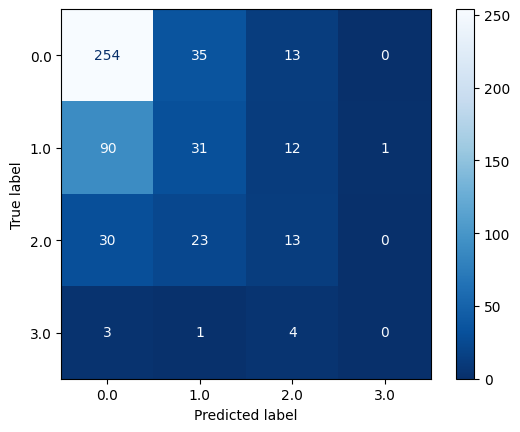

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    estimator=base_model,
    X=new_X_test, y=y_test,
    cmap = 'Blues_r')

We can see that even if it's just the basic model, we have quite balanced predictions, but we want to tune the hyperparameters and get a better model.

### Tuning the Hyperparameter
We will tune the hyperparametersusing a k-fold cross validation that tunes the hyperparameters automatically.<br>
The parameters we are going to tune are:
- learning rate -> how much the model adjust at each step
- depth -> depth of each tree
- iterations -> number of boosting rounds
- L2 regularization -> regularization parameter that helps control model complexity<br>

Other parameter like the loss function will not be tuned since we have 4 possible class labels so we are going to use `MultiClass`.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

base_model = CatBoostClassifier(cat_features=cat_features, loss_function='MultiClass', early_stopping_rounds=50, verbose=0)
parameters = {
    'depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 5, 10],
    'iterations': [100, 200, 500]
}
tuned_model = GridSearchCV(base_model, parameters, cv=5, scoring='accuracy', n_jobs=-1)
tuned_model.fit(new_X_train, y_train)
print ("Best Score: {:.3f}".format(tuned_model.best_score_) )
print("Best Params: ", tuned_model.best_params_)
test_acc = accuracy_score(y_true = y_test, y_pred = tuned_model.predict(new_X_test) )
print("Test Accuracy: {:.3f}".format(test_acc) )

/usr/local/lib/python3.8/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Score: 0.613
Best Params:  {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 10, 'learning_rate': 0.1}
Test Accuracy: 0.600


We got a more accurate model. <br>
Let's investigate better the performance using a Confusion Matrix, in this way we can now which are the label that are better and worst predicted:

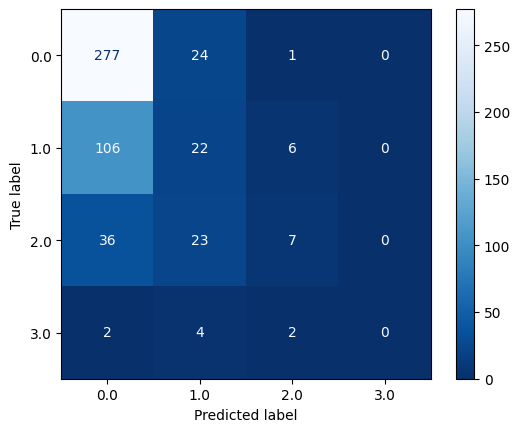

In [8]:
ConfusionMatrixDisplay.from_estimator(
    estimator=tuned_model,
    X=new_X_test, y=y_test,
    cmap = 'Blues_r')

We can see that the model is quite unbalanced, let's see what happen if we try to balance a bit the classes

Test Accuracy: 0.608


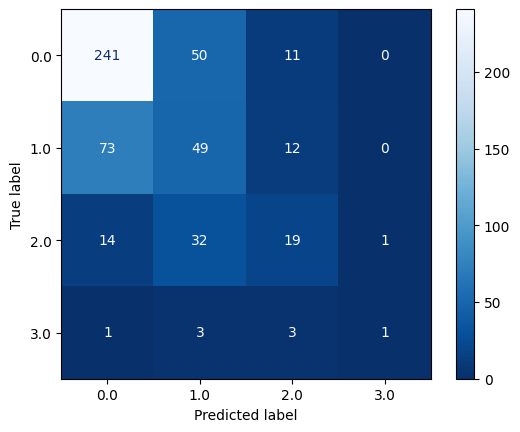

In [12]:
weights = [1,2,4,8]

model = CatBoostClassifier(iterations=500, cat_features=cat_features, depth=8, l2_leaf_reg=5, learning_rate=0.05, 
                                class_weights=weights, loss_function='MultiClass', early_stopping_rounds=50, verbose=0)

model.fit(new_X_train, y_train)
test_acc = accuracy_score(y_true = y_test, y_pred = model.predict(new_X_test) )
print("Test Accuracy: {:.3f}".format(test_acc) )

ConfusionMatrixDisplay.from_estimator(
    estimator=model,
    X=new_X_test, y=y_test,
    cmap = 'Blues_r')

This way we get a more balanced and even more accurate model. There is still a problem with predicting instances of class 3 but that's quite normal since there are very few instances so the model isn't trained a lot on them. <br>
This time we will not give a weight that is inversely proportional to the frequency of a label since the basic model is already slighty balanced and giving inversely proportional weight will compromise the accuracy too much.

### Feature Subset Selection
Now we have a quite balance and tuned model based on all the features of the dataset. <br>
With the goal of adding robustness and reducing overfitting, we will now select a subset of the most useful features. <br>
This time, since `RFECV` doesn't know how to handle categorical variables, we are going to perform the selection of the subset using the embedded approaches, so starting with all the features we compute their importance and remove the least important at every cycle until we got a model where removing features will compromise the performances. <br>

Before starting the selection procedure we will take a look at the most important features:

['Fitness_Endurance-Time_Sec', 'PAQ_A-PAQ_A_Total', 'SDS-SDS_Total_Raw', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday']


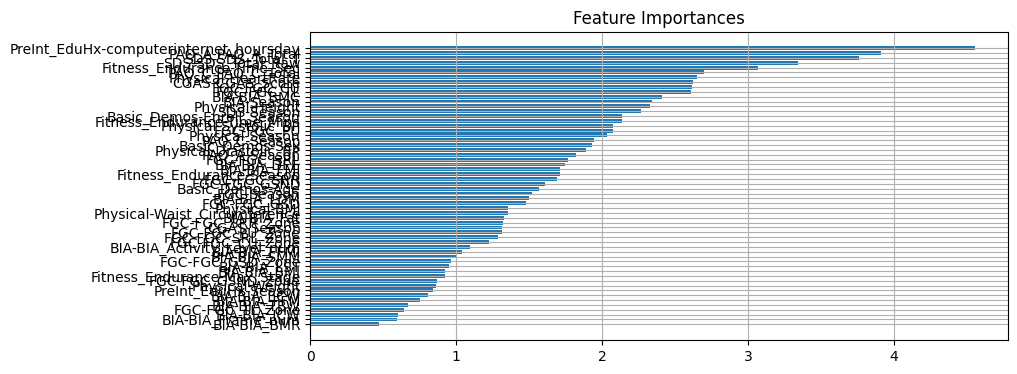

In [22]:
feature_names = new_X_train.columns.tolist()

important_features = [name for name, importance in zip(feature_names, model.get_feature_importance()) if importance > 3]
print(important_features)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(range(new_X_train.shape[1]), sorted(model.get_feature_importance())[::-1])
ax.set_title("Feature Importances")
ax.set_yticks(range(new_X_train.shape[1]))
ax.set_yticklabels(np.array(feature_names)[np.argsort(model.get_feature_importance())[::-1]])
ax.invert_yaxis() 
ax.grid()

We can see that this time the most important features are slighty different from the one we got using RandomForest. <br>
Indeed we got some SDS features that scale to categorize sleep disorders in children like the other time, but this time we also got features relative to:
- Physical Activity Questionnaire: children partecipation in vigorous activities
- Internet use
- FitnessGram: measurements of cardiovascular fitness assessed using the NHANES treadmill protocol <br>

Another important thing we can notice is that this time also categorical values have an importance, probably thanks to CatBoost and it's automatic categorical features management. <br>
We can also notice that this time features about Bio-electric Impedance Analysis are less significative.


We will now perform the selection of the features using as model the last one we computed with tuned hyperparameters and balanced weights. <br>
The selection is going to be a cross validation in this way we can use all the data in the train set for the training step thanks to the fact that every time a different sample of the set is used for the validation part. <br>
For the subset selection we will test the performance of the top $k$ most important features starting from 20 by adding 5 features at time, and we are going to keep the one where an addition of features doesn't give us a better accuracy. <br>

In [14]:
from sklearn.model_selection import cross_val_score

for col in cat_features:
    new_X_train[col] = new_X_train[col].astype('category')
    
best_features = np.argsort(model.get_feature_importance())[::-1]
accuracy = []
for k in range(20,len(best_features),5):
    
    X_subset = new_X_train.iloc[:, best_features[:k]]
    cat = [ X_subset.columns.get_loc(col) for col in cat_features if col in X_subset.columns] # indices of the categorical features that are selecteed by the subset
    sub_model = CatBoostClassifier(iterations=500, cat_features=cat, depth=8, l2_leaf_reg=5, learning_rate=0.05, 
                                class_weights=weights, loss_function='MultiClass', early_stopping_rounds=50, verbose=0)
    scores = cross_val_score(sub_model,
                             new_X_train.iloc[:,best_features[:k]], y_train,
                             cv=5, scoring='accuracy')
    accuracy += [(k, scores.mean())]

In [15]:
print(accuracy)
best_k, best_score = max(accuracy, key=lambda x: x[1]) # key extract the second element (the accuracy) from each tuple
best_k

[(20, 0.5838235294117647), (25, 0.5901960784313726), (30, 0.5794117647058824), (35, 0.5877450980392157), (40, 0.5794117647058823), (45, 0.5882352941176471), (50, 0.5754901960784314), (55, 0.5877450980392157)]


25

We got the higher accuracy with 25, so we are going to keep the best 25 features for the prediction, let's how the classifier behave with the test set and who they are:

In [17]:
sub_features = np.array(feature_names)[best_features[:best_k]]
X_train_subset = new_X_train.iloc[:, best_features[:best_k]]
X_test_subset = new_X_test.iloc[:, best_features[:best_k]]
cat2 = [i for i in cat_features if i in sub_features]
sub_model = CatBoostClassifier(iterations=500, cat_features=cat2, depth=8, l2_leaf_reg=5, learning_rate=0.05, 
                                class_weights=weights, loss_function='MultiClass', early_stopping_rounds=50, verbose=0)

sub_model.fit(X_train_subset, y_train)
test_acc = accuracy_score(y_true = y_test, y_pred = sub_model.predict(X_test_subset) )
print("Test Accuracy: {:.3f}".format(test_acc) )

Test Accuracy: 0.610


The accuracy score is stable and now we also have the benefit of a reduced complexity and a reduced risk of overfit. <br>
Let's get some more insight from the confusion matrix:

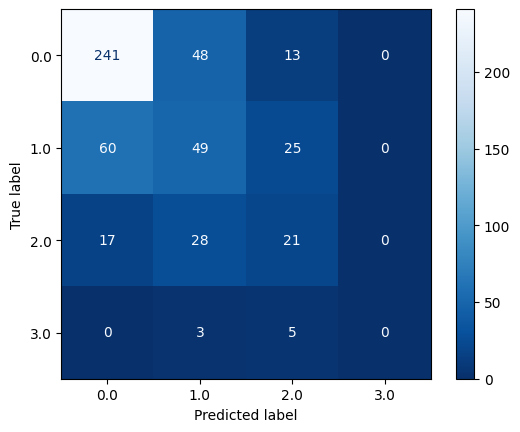

In [18]:
ConfusionMatrixDisplay.from_estimator(
    estimator=sub_model,
    X=X_test_subset, y=y_test,
    cmap = 'Blues_r')

The confusion matrix is quite similiar to the one of the previous model, meaning that the accuracy measures are stable. <br>
Let's now take a look of the selected features:

['PreInt_EduHx-computerinternet_hoursday', 'PAQ_A-PAQ_A_Total', 'SDS-SDS_Total_Raw', 'Fitness_Endurance-Time_Sec', 'Physical-Height', 'BIA-BIA_DEE']


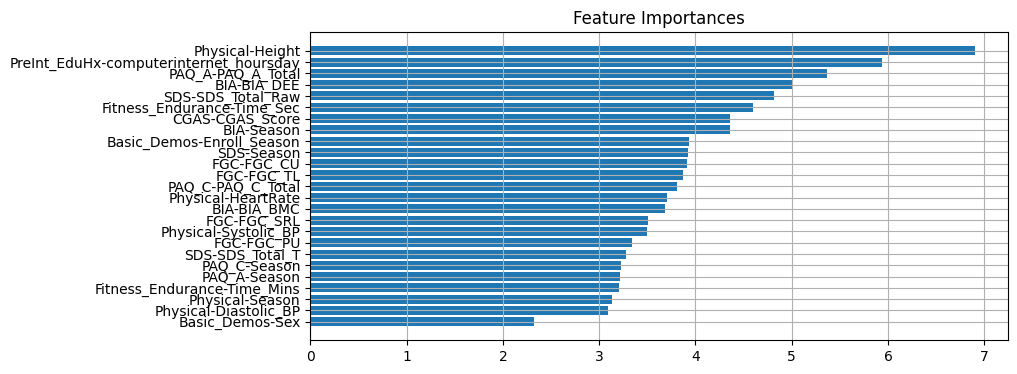

In [21]:
subset_feature_names = X_train_subset.columns.tolist()

important_features = [name for name, importance in zip(subset_feature_names, sub_model.get_feature_importance()) if importance > 4.5]
print(important_features)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(range(X_train_subset.shape[1]), sorted(sub_model.get_feature_importance())[::-1])
ax.set_title("Feature Importances")
ax.set_yticks(range(X_train_subset.shape[1]))
ax.set_yticklabels(np.array(subset_feature_names)[np.argsort(sub_model.get_feature_importance())[::-1]])
ax.invert_yaxis() 
ax.grid()

We can see that the most important features are similiar to the model that include all the features, this means that there wasn't high correlation between the best features and the removed one. <br>
We can also notice that the Physical Measures grow in relevance, this could be thanks to the elimination of attributes which correlation had them penalized.

### Evaluation through Kaggle
We want know to evaluate the model through the `test.csv` dataset that represents the one that the Kaggle competition use for the evaluation. <br>
The submission file have to be of the format (`id`, `sii`), so for each id we have to predict the correct sii. <br>
So we have to transform the test dataset like we did for the training set and then use the definitive model, that is the one with fine tuned parameter and a subset of feature, to predict the labels.

In [45]:
# Process the Data Set
df_test = pd.read_csv("data/test.csv")
ids = df_test['id']
del df_test['id']

physical_measures_df = pd.read_csv('data/physical_measures.csv')

df_test = df_test.merge( physical_measures_df, on=['Basic_Demos-Age', 'Basic_Demos-Sex'], suffixes=('', '_avg'))
cols = ['Physical-BMI','Physical-Height','Physical-Weight','Physical-Waist_Circumference','Physical-Diastolic_BP','Physical-HeartRate','Physical-Systolic_BP']
tot_nan_phys = df_test[cols].isna().all(axis=1)

for col in cols:
    df_test.loc[tot_nan_phys, col] = df_test.loc[tot_nan_phys, f"{col}_avg"]
    del df_test[f"{col}_avg"]

is_numerical = np.array([np.issubdtype(dtype, np.number) for dtype in df_test.dtypes])  
numerical_idx = np.flatnonzero(is_numerical) 
X_test2 = df_test.iloc[:, numerical_idx]


scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=3)

scaled_test = scaler.fit_transform(X_test2)
X_array = imputer.fit_transform(scaled_test)
X_array = scaler.inverse_transform(X_array)
X_test2 = pd.DataFrame(X_array, columns=X_test2.columns, index=X_test2.index)

categorical_idx = np.flatnonzero(is_numerical==False)
categorical_X_test = df_test.iloc[:, categorical_idx]

imputer = SimpleImputer(strategy='most_frequent')
X_array = imputer.fit_transform(categorical_X_test)
categorical_X_test = pd.DataFrame(X_array, columns=categorical_X_test.columns, index=categorical_X_test.index)

new_X_test2 = pd.concat([X_test2, categorical_X_test], axis=1)

Now we are ready to create the csv file for the submission.

In [52]:
X_test_model = new_X_test2.iloc[:, best_features[:best_k]]
y_pred = sub_model.predict(X_test_model).ravel()

submission = pd.DataFrame({
    'id' : ids,
    'sii' : y_pred
})
submission.to_csv('submission.csv',index=False)
submission.head(5)

,id,sii
0,00008ff9,0.0
1,000fd460,0.0
2,00105258,1.0
3,00115b9f,0.0
4,0016bb22,0.0


Using the tuned model with the most informative subset of features we got a maximum private score of 0.412 in the Kaggle evaluation, so we can feel satisfied by our estimator.

### Investigating Problematic Instances
Now that our model is tuned and is based on a subset of features, which makes it less complex and improve computational efficiency, we want to investigate the instances that happen to be the most wrong predictions. <br>
As in the last notebook we will chase them using the probability of prediction and taking the one with more confidence in the wrong class.

In [39]:
y_proba = sub_model.predict_proba(X_test_subset) # for each instances get the probability that it belongs to each class
confidence = np.max(y_proba, axis=1) # we get with what probability an instance was mapped to a class label
y_pred = sub_model.predict(X_test_subset).flatten()
results_df = pd.DataFrame({
    'true_label': y_test,
    'pred_label': y_pred,
    'confidence': confidence
})
results_df['correct'] = results_df['true_label'] == results_df['pred_label']
results_df['index'] = y_test.index

most_wrong = results_df[~results_df['correct']].sort_values(by='confidence', ascending=False).head(500)
print(most_wrong.head(10))

      true_label  pred_label  confidence  correct  index
1163         1.0         0.0    0.908461    False   1163
2544         1.0         0.0    0.898322    False   2544
1247         1.0         0.0    0.890667    False   1247
2585         1.0         0.0    0.852775    False   2585
1148         1.0         0.0    0.835806    False   1148
2252         1.0         0.0    0.804479    False   2252
2525         1.0         0.0    0.785290    False   2525
2363         1.0         0.0    0.777281    False   2363
1455         1.0         0.0    0.755768    False   1455
52           1.0         0.0    0.750226    False     52


We can see that the problem appear mostly when the predicted label is 0 but the true label is 1 or 2. <br>
This is probably due to the fact that class 0 is the one with more instances and even if we have assigned weight to the classes to reduce this unbalance, we still have to deal with it.

We want now to see how these instances behave compared to all the instances. <br>
To do this we will use the same method we used with the Random Forest model, so plot the distribution of the most wrong instances and look at the differences with the distribution of all the instances. <br>
We will focus on the distribution of the most important features since they are the one that have a greatest influence on the model.

In [40]:
important_features = [name for name, importance in zip(subset_feature_names, sub_model.get_feature_importance()) if importance > 5]
print(important_features)
n = len(important_features)
X_test_subset = X_test_subset[X_test_subset['BIA-BIA_DEE']<20000]

['PreInt_EduHx-computerinternet_hoursday', 'PAQ_A-PAQ_A_Total', 'Physical-Height', 'BIA-BIA_DEE']


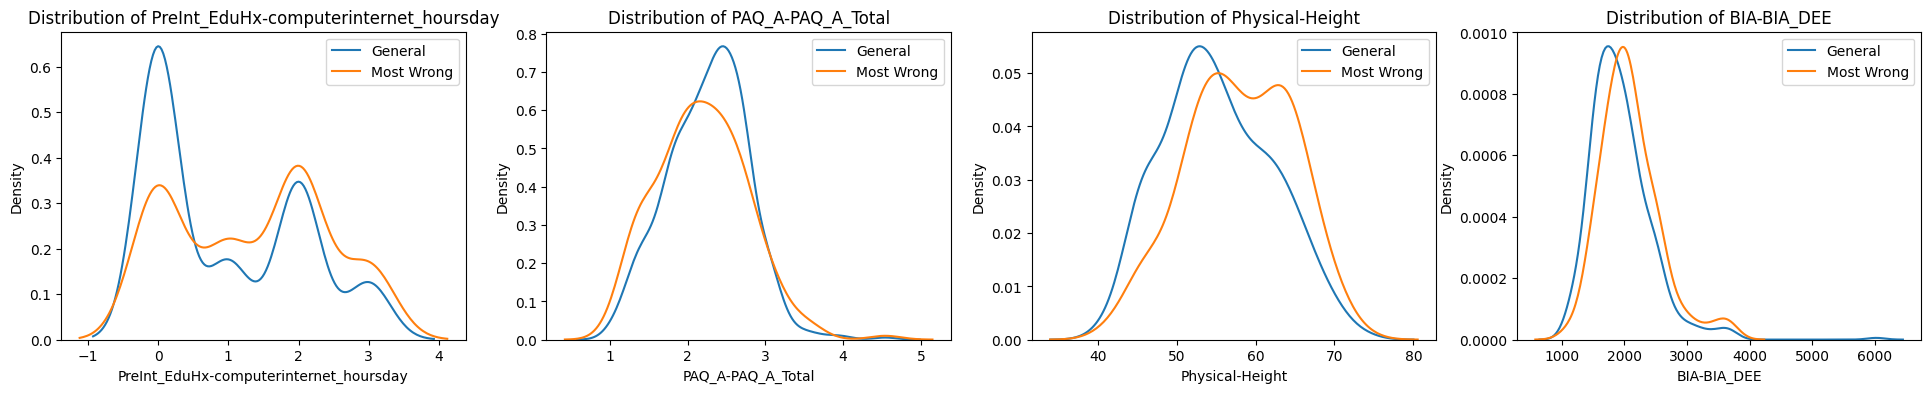

In [41]:
import seaborn as sns
fig, ax = plt.subplots(1, n, figsize=(n*6,n))

for i in range(len(important_features)):
    sns.kdeplot(X_test_subset[important_features[i]], label='General', ax=ax[i])
    sns.kdeplot(X_test_subset.loc[most_wrong['index']][important_features[i]], label='Most Wrong', ax=ax[i])

    ax[i].legend()
    ax[i].set_xlabel(important_features[i])
    ax[i].set_ylabel('Density')
    ax[i].set_title(f'Distribution of {important_features[i]}')

We are also curious of the instances that were the easiest to predict. <br>
They are the one that have the highest confidence and a correct prediction.

In [43]:
most_correct = results_df[results_df['correct']].sort_values(by='confidence', ascending=False).head(500)
print(most_correct.head(10))

      true_label  pred_label  confidence  correct  index
2159         0.0         0.0    0.912420     True   2159
1070         0.0         0.0    0.912211     True   1070
2528         0.0         0.0    0.899750     True   2528
2105         0.0         0.0    0.895737     True   2105
1215         0.0         0.0    0.894613     True   1215
1145         0.0         0.0    0.889777     True   1145
931          0.0         0.0    0.888475     True    931
1138         0.0         0.0    0.884851     True   1138
1245         0.0         0.0    0.878544     True   1245
1224         0.0         0.0    0.878128     True   1224


We can see that they are all instances of class 0. <br>
We could have expect that since they are the one with more instances so there were more data to train with. <br>
A difference we can see between CatBoost and Random Forest is that CatBoost is on average more confident on the prediction than the Random Forest, which can be seen as a more well-calibrated model or overfitting when the prediction is not accurate.

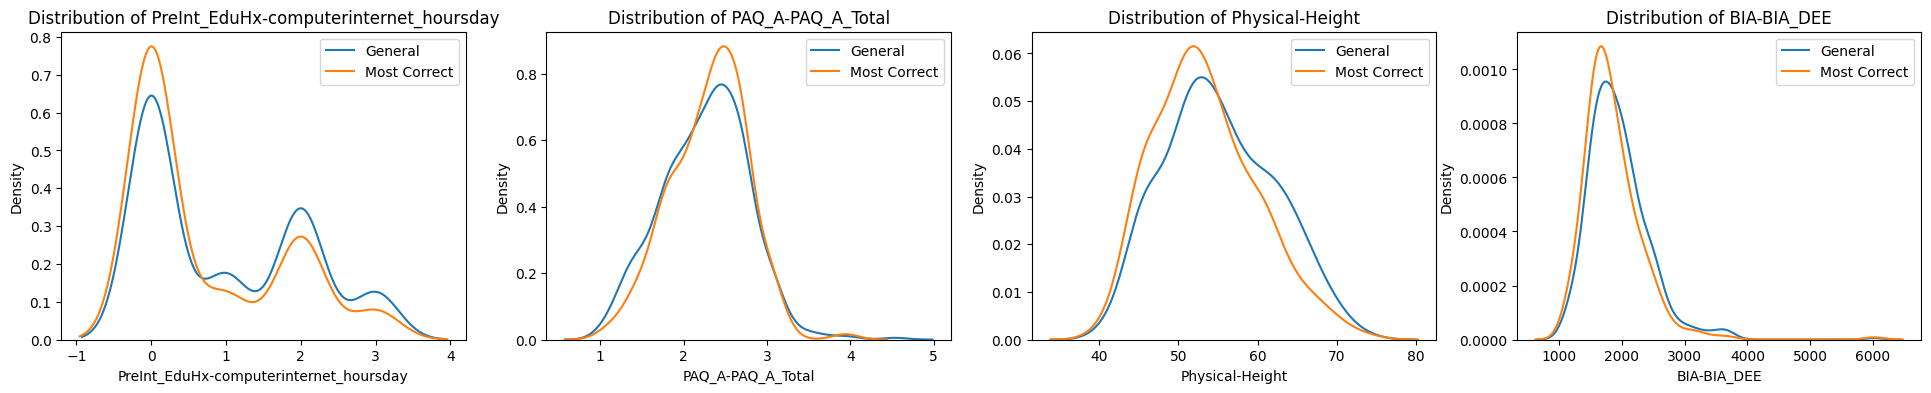

In [44]:
import seaborn as sns
fig, ax = plt.subplots(1, n, figsize=(n*6,n))

for i in range(len(important_features)):
    sns.kdeplot(X_test_subset[important_features[i]], label='General', ax=ax[i])
    sns.kdeplot(X_test_subset.loc[most_correct['index']][important_features[i]], label='Most Correct', ax=ax[i])

    ax[i].legend()
    ax[i].set_xlabel(important_features[i])
    ax[i].set_ylabel('Density')
    ax[i].set_title(f'Distribution of {important_features[i]}')

We can see that the distribution of the easiest to predict is the opposite of the most wrong instances. <br>
Indeed for what concerns the use of internet per day we get an higher density when the number is 0 and a lower density when the hours are 2 or 3, this can be due to the fact that usually kids with more hours of internet use are the one that are more affected to dependency which are the classes that our predictor have more difficulties to predict. <br>
The distribution of the Sleep disturbance scale is quite the same with a slighty higher density when the value is lower. <br>
For what concerns physical height we can see that shorter child are the easier to predict, this could be due to the fact that a shorter child is also younger and for a small kid it's difficult to have an high sii so it's easier to be predicted by our model.